# Semantic abstraction graphicalizer

Thin experiment notebook: configure the run, invoke the package, and visualize the resulting graph, sample a connected subgraph, and narrate it.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import textwrap

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'assets').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'assets').exists():
    raise FileNotFoundError('Could not locate the repository assets directory.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from graphicalizer import (
    ExtractionDensityConfig,
    Graphicalizer,
    GraphicalizerConfig,
    NodeContextConfig,
    SubgraphNarrator,
    SubgraphNarrativeConfig,
    SubgraphNarrativePrompt,
    sample_random_connected_subgraph,
    graph_to_dot,
    load_ontology,
    load_text,
    render_graph,
    validate_ontology_labeled_graph,
)
from IPython.display import SVG, display

## Configure and run

In [2]:
ASSETS_ROOT = PROJECT_ROOT / 'assets'
ABSTRACT_PATH = ASSETS_ROOT / 'abstracts' / 'pathogen_abstract_nipah_virus.txt'
ONTOLOGY_PATH = ASSETS_ROOT / 'ontologies' / 'entity_ontology_microbiology.yaml'
PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'graphicalizer_prompt_template.yaml'
PROMPT_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'ontology-aware-graphicalizer-0.4.0.yaml'
GRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_ontology_graph.svg'
LLM_PROVIDER = 'openai'  # choose 'openai' or 'ollama'
LLM_MODEL = 'gpt-4o-mini' if LLM_PROVIDER == 'openai' else 'gemma4:12b-mlx' # 'gpt-4o-mini' 'gpt-5-nano'
LLM_OPTIONS = (
    {'max_output_tokens': 16384}
    if LLM_PROVIDER == 'openai'
    else {'num_ctx': 32768, 'num_predict': -1}
)

abstract_text = load_text(ABSTRACT_PATH)
ontology = load_ontology(ONTOLOGY_PATH)
ENTITY_EFFORT = 0.1
RELATION_EFFORT = 1.5
density = ExtractionDensityConfig(
    entities_per_word=ENTITY_EFFORT,
    relations_per_entity=RELATION_EFFORT,
)
context = NodeContextConfig(
    max_sentences=3,
    max_evidence_items=2,
    include_evidence=True,
    include_uncertainty=True,
)
config = GraphicalizerConfig(
    provider=LLM_PROVIDER,
    model=LLM_MODEL,
    extraction_density=density,
    node_context=context,
    prompt_template_path=PROMPT_PATH,
    prompt_snapshot_path=PROMPT_SNAPSHOT_PATH,
    disconnected_policy='largest_component',
    context_policy='all_nodes',
    casting_retries=2,
)

graphicalizer = Graphicalizer.from_provider(ontology, config, options=LLM_OPTIONS)
result = graphicalizer.run(abstract_text)

In [3]:
print('Model:', config.model)
print('Source SHA-256:', result.run_metadata['source_sha256'])
print('Raw validation:', result.raw_validation.to_dict())
print('Normalized validation:', result.normalized_validation.to_dict())
print('Normalization report:', result.normalization_report)
print('Final validation:', result.final_validation.to_dict())
print('Entities:', len(result.normalized_extraction.entities))
print('Relations:', len(result.ontology_casting.relations))
print('Node contexts:', len(result.node_contexts))

Model: gpt-4o-mini
Source SHA-256: 42466a9525771b6f88f34965debc73799d4e2e4e24ceb6ba20097bf948388589
Raw validation: {'valid': False, 'connected': False, 'sparse': True, 'node_count': 9, 'edge_count': 6, 'density': 0.16666666666666666, 'max_neighbor_count': 4, 'hub_nodes': (), 'issues': ('graph is disconnected',), 'density_ok': True, 'hubs_ok': True}
Normalized validation: {'valid': False, 'connected': True, 'sparse': True, 'node_count': 6, 'edge_count': 5, 'density': 0.3333333333333333, 'max_neighbor_count': 4, 'hub_nodes': ('e1',), 'issues': ('graph contains 1 hub node(s): e1',), 'density_ok': True, 'hubs_ok': False}
Normalization report: {'policy': 'largest_component', 'component_count': 3, 'retained_entity_ids': ('e1', 'e2', 'e3', 'e4', 'e6', 'e7'), 'discarded_entity_ids': ('e5', 'e8', 'e9'), 'retained_relation_ids': ('r1', 'r2', 'r4', 'r5', 'r6'), 'discarded_relation_ids': ('r3',)}
Final validation: {'valid': False, 'connected': True, 'sparse': True, 'node_count': 6, 'edge_count': 

## Visualize the typed graph

digraph "NipahVirusZoonoticGraph" {
  rankdir=LR;
  "e1" [label="virus\nNipah virus", shape=box];
  "e2" [label="reservoir_host\nfruit bats", shape=box];
  "e3" [label="contaminated_material\nraw date-palm sap", shape=box];
  "e4" [label="geographic_location\nBangladesh", shape=box];
  "e6" [label="genomic_sequence\nviral RNA", shape=box];
  "e7" [label="reservoir_host\nPteropus bats", shape=box];
  "e1" -> "e3" [color="#555555", label="causes_infection"];
  "e1" -> "e4" [color="#555555", label="occurred_in"];
  "e1" -> "e6" [color="#555555", label="detects"];
  "e2" -> "e3" [color="#555555", label="contaminates"];
  "e7" -> "e1" [color="#555555", label="supports"];
}



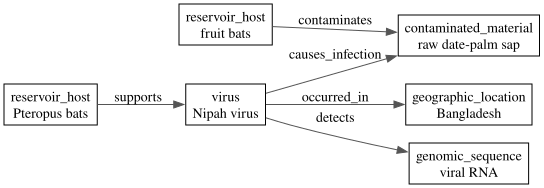

In [4]:
validate_ontology_labeled_graph(result.typed_graph)
dot_text = graph_to_dot(
    result.typed_graph,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
print(dot_text)
render_graph(
    result.typed_graph,
    GRAPH_OUTPUT_PATH,
    graph_name='NipahVirusZoonoticGraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(GRAPH_OUTPUT_PATH)))

## Sample and narrate a connected subgraph

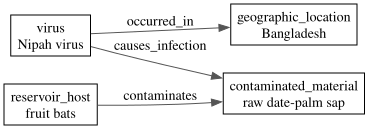

In [41]:
SUBGRAPH_NODE_COUNT = 4
SUBGRAPH_SEED = None
NARRATIVE_WORDS = 100
NARRATIVE_COLUMNS = 80
SUBGRAPH_OUTPUT_PATH = PROJECT_ROOT / 'outputs' / 'nipah_random_subgraph.svg'
NARRATIVE_PROMPT_PATH = ASSETS_ROOT / 'prompts' / 'subgraph_narrative_prompt_template.yaml'
NARRATIVE_SNAPSHOT_PATH = PROJECT_ROOT / 'outputs' / 'prompts' / 'subgraph-narrator-0.1.0.yaml'

sampled_subgraph = sample_random_connected_subgraph(
    result.typed_graph,
    num_nodes=SUBGRAPH_NODE_COUNT,
    seed=SUBGRAPH_SEED,
)
validate_ontology_labeled_graph(sampled_subgraph)
render_graph(
    sampled_subgraph,
    SUBGRAPH_OUTPUT_PATH,
    graph_name='NipahRandomSubgraph',
    require_ontology_labels=True,
)
display(SVG(filename=str(SUBGRAPH_OUTPUT_PATH)))

In [42]:

narrator_prompt = SubgraphNarrativePrompt.from_yaml_file(NARRATIVE_PROMPT_PATH)
narrator = SubgraphNarrator.from_graphicalizer(
    graphicalizer,
    prompt=narrator_prompt,
    prompt_snapshot_path=NARRATIVE_SNAPSHOT_PATH,
)
narrative = narrator.narrate(
    sampled_subgraph,
    SubgraphNarrativeConfig(target_words=NARRATIVE_WORDS),
)
print(textwrap.fill(narrative.narrative, width=NARRATIVE_COLUMNS))
print('Requested words:', narrative.requested_words)
print('Actual words:', narrative.actual_words)
if narrative.uncertainty:
    print('Uncertainty:', narrative.uncertainty)


The Nipah virus, a zoonotic paramyxovirus, is maintained in fruit bat
populations (genus Pteropus) and primarily infects humans through the
consumption of contaminated raw date-palm sap. Evidence shows that most
confirmed cases report sap consumption, which acts as a transmission vector for
the virus. Notably, an outbreak of acute febrile encephalitis occurred in a
rural community in Bangladesh, linked to these infections during the date-palm
sap harvesting season. While the relationship between fruit bats and sap
contamination suggests a zoonotic spillover mechanism, uncertainties remain
regarding specific contamination circumstances and potential human-to-human
transmission.
Requested words: 100
Actual words: 92
Uncertainty: The connection of individual cases to person-to-person transmission is less clear, with limited evidence of sustained transmission.


## Inspect node contexts

In [7]:
for node_context in result.node_contexts:
    print(f'\n[{node_context.entity_id}] {node_context.summary}')
    for evidence in node_context.evidence:
        print(f'  evidence: {evidence}')
    if node_context.uncertainty:
        print(f'  uncertainty: {node_context.uncertainty}')


[e1] Nipah virus, a zoonotic paramyxovirus, causes infection in humans primarily through consumption of contaminated raw date-palm sap, following its contamination by fruit bats.
  evidence: Most confirmed patients reported consuming raw date-palm sap.
  evidence: Viral RNA was detected in residual sap.
  uncertainty: The connection of individual cases to person-to-person transmission is less clear, with limited evidence of sustained transmission.

[e2] Fruit bats are identified as the reservoir hosts of the Nipah virus, contaminating raw date-palm sap, which is linked to human infections.
  evidence: findings support a zoonotic spillover pathway in which Pteropus fruit bats contaminate raw date-palm sap.
  uncertainty: The role of specific bat species in the spillover mechanism requires further investigation.

[e3] Raw date-palm sap is a contaminated material through which the Nipah virus is transmitted to humans, notably during the winter harvesting season in Bangladesh.
  evidence: